In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.te
import kagglehub
dshah1612_product_tweets_dataset_path = kagglehub.dataset_download('dshah1612/product-tweets-dataset')

print('Data source import complete.')


100%|██████████| 367k/367k [00:00<00:00, 604kB/s]

Extracting files...
Data source import complete.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [8]:
df=pd.read_csv('train02.csv',encoding='latin1')
df.head()

,text,emotion
0,i feel awful about it too because it s my job ...,0.0
1,im alone i feel awful,0.0
2,ive probably mentioned this before but i reall...,1.0
3,i was feeling a little low few days back,0.0
4,i beleive that i am much more sensitive to oth...,2.0


In [9]:
df.columns=['text','emotion']
df.head()

,text,emotion
0,i feel awful about it too because it s my job ...,0.0
1,im alone i feel awful,0.0
2,ive probably mentioned this before but i reall...,1.0
3,i was feeling a little low few days back,0.0
4,i beleive that i am much more sensitive to oth...,2.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41595 entries, 0 to 41594
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   text     41595 non-null  object 
 1   emotion  41594 non-null  float64
dtypes: float64(1), object(1)
memory usage: 650.1+ KB


  <h1><center>Dealing with null values</center></h1>

<Axes: >

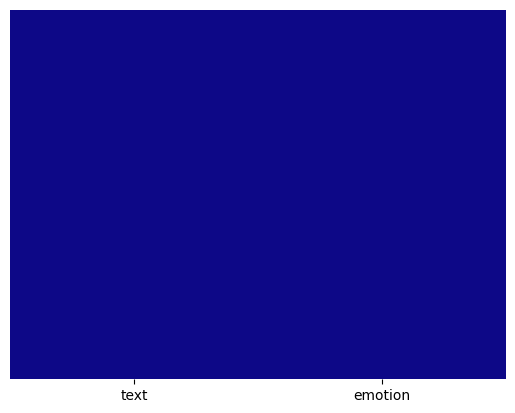

In [11]:
sns.heatmap(df.isnull(),cmap='plasma',cbar=False,yticklabels=False)

**We can see that most of the values in the product column are null values and hence would not provide great insights for the data, so it would be better to drop the column**

In [ ]:
#df.drop('product',axis=1,inplace=True)
#df.head()

In [12]:
df.isnull().sum()

,0
text,0
emotion,1


In [ ]:
df.dropna(inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41595 entries, 0 to 41594
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   text     41595 non-null  object 
 1   emotion  41594 non-null  float64
dtypes: float64(1), object(1)
memory usage: 650.1+ KB


**All the null values have been removed from the dataset and so we can proceed to the part of Text Preprocessing**

  <h1><center>Text Preprocessing</center></h1>

In [14]:
df.head()

,text,emotion
0,i feel awful about it too because it s my job ...,0.0
1,im alone i feel awful,0.0
2,ive probably mentioned this before but i reall...,1.0
3,i was feeling a little low few days back,0.0
4,i beleive that i am much more sensitive to oth...,2.0


### Emotion column

In [15]:
df['emotion'].value_counts()

,count
emotion,
1.0,14017
0.0,12126
3.0,5603
4.0,4813
2.0,3476
5.0,1559


In [ ]:
# combining "I can't tell" with "No emotion toward brand or product"
#df['emotion'].replace("I can't tell","No emotion toward brand or product",inplace=True)

In [16]:
df['emotion'].value_counts()

,count
emotion,
1.0,14017
0.0,12126
3.0,5603
4.0,4813
2.0,3476
5.0,1559


In [ ]:
# mapping each of the types to a numeric value
# "Negative emotion" -----> 0
# "No emotion toward brand or product" -----> 1
# "Positive emotion" -----> 2
#df['emotion']=df['emotion'].map({"Negative emotion":0,"No emotion toward brand or product":1,"Positive emotion":2})

In [17]:
df['emotion'].value_counts()

,count
emotion,
1.0,14017
0.0,12126
3.0,5603
4.0,4813
2.0,3476
5.0,1559


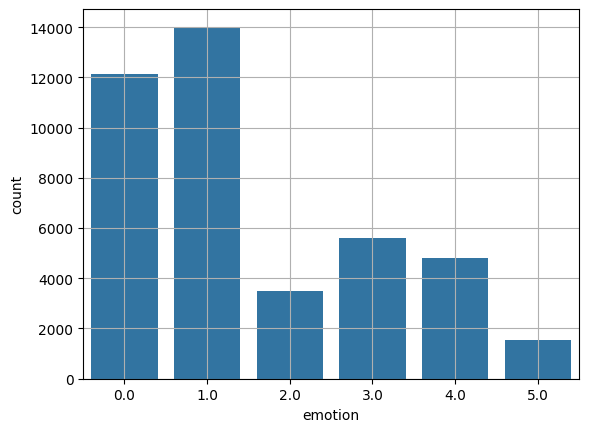

In [18]:
sns.countplot(x='emotion',data=df)
plt.grid()

### Text column

In [20]:
import re

In [19]:
# converting the text to lowercase
df['text']=df['text'].apply(lambda x:x.lower())

In [21]:
df.head()

,text,emotion
0,i feel awful about it too because it s my job ...,0.0
1,im alone i feel awful,0.0
2,ive probably mentioned this before but i reall...,1.0
3,i was feeling a little low few days back,0.0
4,i beleive that i am much more sensitive to oth...,2.0


In [22]:
# removing hyperlinks from the text
df['text']=df['text'].apply(lambda x:re.sub('http[s]?://\S+',' ', x))

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_7200/1012724528.py:2: SyntaxWarning: invalid escape sequence '\S'
  df['text']=df['text'].apply(lambda x:re.sub('http[s]?://\S+',' ', x))


In [23]:
# removing non alphabetical characters from the text
df['text']=df['text'].apply(lambda x:re.sub(r'[^a-z]+',' ',x))

In [24]:
df.head()

,text,emotion
0,i feel awful about it too because it s my job ...,0.0
1,im alone i feel awful,0.0
2,ive probably mentioned this before but i reall...,1.0
3,i was feeling a little low few days back,0.0
4,i beleive that i am much more sensitive to oth...,2.0


In [25]:
# multiple spaces to a single space
df['text']=df['text'].apply(lambda x:" ".join(x.split()))

In [26]:
# adding a column of length for better insights
df['length']=df['text'].apply(len)

In [27]:
df.head(3)

,text,emotion,length
0,i feel awful about it too because it s my job ...,0.0,112
1,im alone i feel awful,0.0,21
2,ive probably mentioned this before but i reall...,1.0,152


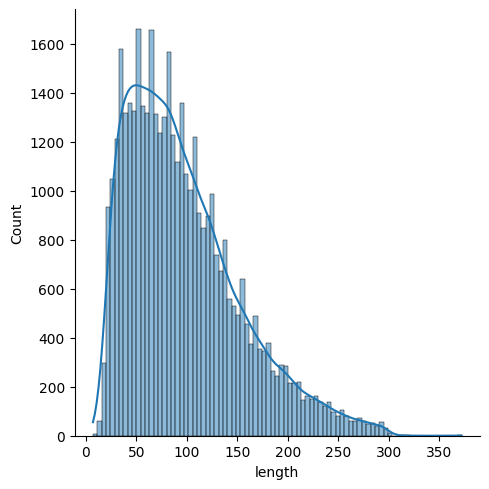

In [28]:
# distribution of the length of the reviews
sns.displot(df['length'],kde=True)

<Axes: xlabel='emotion', ylabel='length'>

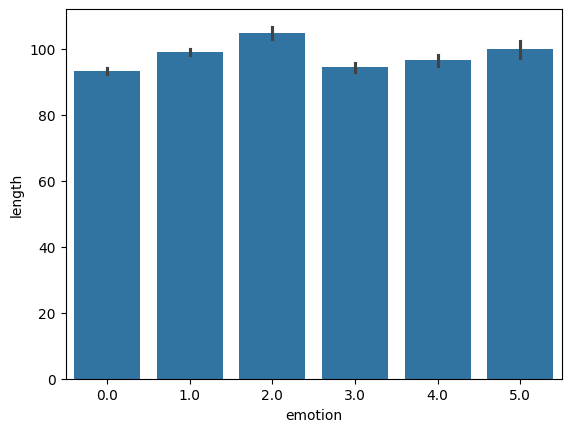

In [29]:
sns.barplot(x='emotion',y='length',data=df)

array([[<Axes: title={'center': '0.0'}>, <Axes: title={'center': '1.0'}>],
       [<Axes: title={'center': '2.0'}>, <Axes: title={'center': '3.0'}>],
       [<Axes: title={'center': '4.0'}>, <Axes: title={'center': '5.0'}>]],
      dtype=object)

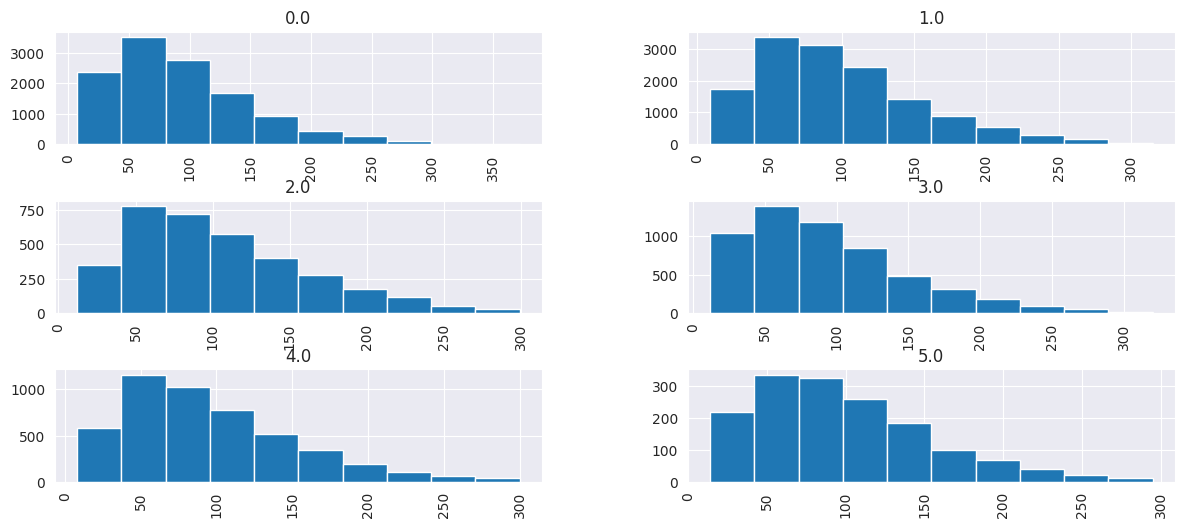

In [30]:
sns.set_style('darkgrid')
df.hist(column='length',by='emotion',figsize=(14,6))

### Tokenizing and removing stopwords

In [31]:
import nltk
from nltk.corpus import stopwords

In [32]:
def stopwords_removal(text):
    return [w for w in text.split() if w not in stopwords.words('english')]

In [33]:
nltk.download('stopwords', quiet=True)
df['text']=df['text'].apply(stopwords_removal)

In [34]:
df.head()

,text,emotion,length
0,"[feel, awful, job, get, position, succeed, hap...",0.0,112
1,"[im, alone, feel, awful]",0.0,21
2,"[ive, probably, mentioned, really, feel, proud...",1.0,152
3,"[feeling, little, low, days, back]",0.0,40
4,"[beleive, much, sensitive, peoples, feelings, ...",2.0,99


In [35]:
#dropping the length column
df.drop('length',axis=1,inplace=True)

In [36]:
from nltk.stem import WordNetLemmatizer

In [37]:
def lemmatizer(text):
    lemma=WordNetLemmatizer()
    return [lemma.lemmatize(w) for w in text]

In [38]:
import nltk
nltk.download('wordnet', quiet=True)
df['text']=df['text'].apply(lemmatizer)

In [39]:
df.head()

,text,emotion
0,"[feel, awful, job, get, position, succeed, hap...",0.0
1,"[im, alone, feel, awful]",0.0
2,"[ive, probably, mentioned, really, feel, proud...",1.0
3,"[feeling, little, low, day, back]",0.0
4,"[beleive, much, sensitive, people, feeling, te...",2.0


In [40]:
# removing one length words and the word "sxsw"
def one_letter_word_removal(text):
    return [w for w in text if len(w)>1 and w!="sxsw"]

df['text']=df['text'].apply(one_letter_word_removal)
df.head(3)

,text,emotion
0,"[feel, awful, job, get, position, succeed, hap...",0.0
1,"[im, alone, feel, awful]",0.0
2,"[ive, probably, mentioned, really, feel, proud...",1.0


In [41]:
# joining the list of words to form the review
df['text']=df['text'].apply(lambda x:" ".join(x))
df.head()

,text,emotion
0,feel awful job get position succeed happen,0.0
1,im alone feel awful,0.0
2,ive probably mentioned really feel proud actua...,1.0
3,feeling little low day back,0.0
4,beleive much sensitive people feeling tend com...,2.0


### Bag of Words transformer

In [42]:
from sklearn.feature_extraction.text import CountVectorizer

In [43]:
# fitting the bow transformer to the text column and transforming it
######AVOIIIIDDDD
bow_transformer=CountVectorizer().fit(df['text'])

In [ ]:
##import nltk

In [44]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [45]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [46]:
# total number of different words present in the corpus
print(len(bow_transformer.vocabulary_))

21955


**So there are 8362 unique words in the entire text column**

In [47]:
sample_text=df['text'][0]
sample_text

'feel awful job get position succeed happen'

In [48]:
# vector representation of the sample_text
bow_sample=bow_transformer.transform([sample_text])
print(bow_sample)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (1, 21955)>
  Coords	Values
  (0, 1324)	1
  (0, 7021)	1
  (0, 7954)	1
  (0, 8594)	1
  (0, 10370)	1
  (0, 14674)	1
  (0, 18714)	1


In [49]:
# applying the bow transformer to the entire column
text_bow=bow_transformer.transform(df['text'])

In [50]:
print("The shape of the matrix is: ",text_bow.shape)
# 9092 different reviews and 7046 unique words in the entire corpus

The shape of the matrix is:  (41595, 21955)


In [51]:
print("The number of non zero values in the matrix: ",text_bow.nnz)

The number of non zero values in the matrix:  373396


In [52]:
print("Sparcity of the matrix: ",100*text_bow.nnz/(text_bow.shape[0]*text_bow.shape[1]))

Sparcity of the matrix:  0.040887926869834425


The matrix is very sparse since most of the values would be zero

### Term Frequency - Inverse Document Frequency (Tf-Idf) Transformer

In [53]:
from sklearn.feature_extraction.text import TfidfTransformer

In [54]:
tfidf_transformer=TfidfTransformer().fit(text_bow)
tfidf_sample=tfidf_transformer.transform(bow_sample)
print(tfidf_sample)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7 stored elements and shape (1, 21955)>
  Coords	Values
  (0, 1324)	0.3935584607152267
  (0, 7021)	0.08339635292018475
  (0, 7954)	0.245093427318906
  (0, 8594)	0.3903252774138515
  (0, 10370)	0.3612254954585949
  (0, 14674)	0.44979880811070505
  (0, 18714)	0.5412294796745898


In [55]:
# applying the tfidf_transformer to the entire column
text_tfidf=tfidf_transformer.transform(text_bow)
print(text_tfidf.shape)

(41595, 21955)


### Train Test Split

In [56]:
X=df['text']
y=df['emotion']

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
# splitting the dataset into 75% train and 25% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [59]:
print(len(X_train),len(X_test),len(X_train)+len(X_test))

31196 10399 41595


  <h1><center>Model Creation and Evaluation</center></h1>

The task of Bag-of-Words transformer followed by the Tf-Idf transformer and model creation can all be done in one single step using a pipeline provided by Scikit Learn

In [60]:
from sklearn.pipeline import Pipeline

### Multinomial Naive Bayes

In [61]:
from sklearn.naive_bayes import MultinomialNB

In [62]:
pipe1=Pipeline([
    ('bow',CountVectorizer()),    # strings to integer token counts
    ('tfidf',TfidfTransformer()),  # tokens counts to TF-IDF weights
    ('classifier',MultinomialNB())  # classification algorithm
])

In [64]:
import pandas as pd

# fitting the pipeline
# Identify rows in y_train that are not NaN
non_nan_indices = y_train.notna()

# Filter X_train and y_train to remove corresponding NaN values
X_train_cleaned = X_train[non_nan_indices]
y_train_cleaned = y_train[non_nan_indices]

pipe1.fit(X_train_cleaned, y_train_cleaned)

Pipeline(steps=[('bow', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('classifier', MultinomialNB())])

In [65]:
# making predictions
predictions_nb=pipe1.predict(X_test)

In [66]:
predictions_nb

array([1., 0., 0., ..., 0., 1., 0.])

In [67]:
from sklearn.metrics import classification_report,confusion_matrix

In [68]:
def metrics(y_true,y_pred):
    print(classification_report(y_true,y_pred))
    print("\n")
    print(confusion_matrix(y_true,y_pred))

In [69]:
metrics(y_test,predictions_nb)

              precision    recall  f1-score   support

         0.0       0.73      0.94      0.83      3102
         1.0       0.65      0.98      0.78      3490
         2.0       0.99      0.09      0.17       888
         3.0       0.96      0.43      0.60      1378
         4.0       0.87      0.32      0.46      1149
         5.0       1.00      0.03      0.06       392

    accuracy                           0.71     10399
   macro avg       0.87      0.47      0.48     10399
weighted avg       0.78      0.71      0.65     10399



[[2930  169    0    2    1    0]
 [  83 3406    0    0    1    0]
 [ 112  689   83    1    3    0]
 [ 392  366    0  599   21    0]
 [ 349  413    1   22  364    0]
 [ 125  225    0    2   28   12]]


### Logistic Regression

In [70]:
from sklearn.linear_model import LogisticRegression

In [71]:
pipe2=Pipeline([
    ('bow',CountVectorizer()),    # strings to integer token counts
    ('tfidf',TfidfTransformer()),  # tokens counts to TF-IDF weights
    ('classifier',LogisticRegression())  # classification algorithm
])

In [73]:
pipe2.fit(X_train_cleaned,y_train_cleaned)

Pipeline(steps=[('bow', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('classifier', LogisticRegression())])

In [74]:
predictions_lg=pipe2.predict(X_test)

In [75]:
metrics(y_test,predictions_lg)

              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93      3102
         1.0       0.87      0.94      0.90      3490
         2.0       0.85      0.68      0.76       888
         3.0       0.91      0.85      0.88      1378
         4.0       0.83      0.85      0.84      1149
         5.0       0.87      0.62      0.72       392

    accuracy                           0.88     10399
   macro avg       0.87      0.81      0.84     10399
weighted avg       0.88      0.88      0.88     10399



[[2905   88    9   52   46    2]
 [  51 3293   88   22   20   16]
 [  25  245  603    6    8    1]
 [  81   72    6 1169   49    1]
 [  69   57    0   31  974   18]
 [  16   49    0    3   80  244]]


### Random Forest Classifier

In [76]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
pipe3=Pipeline([
    ('bow',CountVectorizer()),    # strings to integer token counts
    ('tfidf',TfidfTransformer()),  # tokens counts to TF-IDF weights
    ('classifier',RandomForestClassifier(n_estimators=400))  # classification algorithm
])

In [79]:
pipe3.fit(X_train_cleaned,y_train_cleaned)

Pipeline(steps=[('bow', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('classifier', RandomForestClassifier(n_estimators=400))])

In [80]:
predictions_rf=pipe3.predict(X_test)
#X_train_cleaned

In [81]:
metrics(y_test,predictions_rf)

              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93      3102
         1.0       0.91      0.92      0.91      3490
         2.0       0.84      0.73      0.78       888
         3.0       0.87      0.88      0.88      1378
         4.0       0.81      0.87      0.84      1149
         5.0       0.77      0.72      0.74       392

    accuracy                           0.89     10399
   macro avg       0.86      0.84      0.85     10399
weighted avg       0.89      0.89      0.89     10399



[[2879   51   17   85   59   11]
 [  81 3204  100   38   43   24]
 [  15  204  651    7    7    4]
 [  65   29    7 1218   54    5]
 [  45   15    2   45 1001   41]
 [   4   37    0    2   66  283]]


### SVM

In [82]:
from sklearn.svm import SVC

In [83]:
pipe4=Pipeline([
    ('bow',CountVectorizer()),    # strings to integer token counts
    ('tfidf',TfidfTransformer()),  # tokens counts to TF-IDF weights
    ('classifier',SVC())  # classification algorithm
])

In [85]:
pipe4.fit(X_train_cleaned,y_train_cleaned)
#X_train_cleaned

Pipeline(steps=[('bow', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('classifier', SVC())])

In [86]:
predictions_svc=pipe4.predict(X_test)

In [87]:
metrics(y_test,predictions_svc)

              precision    recall  f1-score   support

         0.0       0.92      0.93      0.93      3102
         1.0       0.86      0.94      0.90      3490
         2.0       0.85      0.64      0.73       888
         3.0       0.92      0.83      0.87      1378
         4.0       0.80      0.88      0.84      1149
         5.0       0.86      0.61      0.71       392

    accuracy                           0.88     10399
   macro avg       0.87      0.80      0.83     10399
weighted avg       0.88      0.88      0.87     10399



[[2887   83   20   53   50    9]
 [  64 3280   71   25   36   14]
 [  19  288  570    1    8    2]
 [  91   69    9 1141   64    4]
 [  63   55    1   15 1006    9]
 [  14   50    0    1   89  238]]


**Hyper-Parameter Tuning**

In [88]:
from sklearn.model_selection import RandomizedSearchCV

In [89]:
# For using RandomizedSearchCV we would need to specify the parameters and their corresponding values on which it would work
# and find the best values

C=[0.1,1,10,20,50,100]
gamma=[0.0001,0.001,0.1,1,10]
kernel=['rbf','linear','sigmoid']

In [90]:
random_grid = {'C': C,
               'gamma': gamma,
               'kernel': kernel}

In [91]:
model_svc_tuned=SVC()

In [92]:
SVC_tuned = RandomizedSearchCV(estimator = model_svc_tuned,
                               param_distributions = random_grid,
                               n_iter = 20, cv = 2, verbose=2,
                               random_state=42,n_jobs=-1)

In [93]:
# we need to split the data based on the tfidf transformed matrix which earlier was done as part of the pipeline
X_train_tuned, X_test_tuned, y_train_tuned, y_test_tuned = train_test_split(text_tfidf, df['emotion'], test_size=0.25)

In [96]:
# Before fitting, ensure y_train_tuned does not contain NaN values
nan_mask = y_train_tuned.isna()
X_train_tuned_cleaned = X_train_tuned[~nan_mask.values]
y_train_tuned_cleaned = y_train_tuned[~nan_mask]

SVC_tuned.fit(X_train_tuned_cleaned, y_train_tuned_cleaned)

Fitting 2 folds for each of 20 candidates, totalling 40 fits


RandomizedSearchCV(cv=2, estimator=SVC(), n_iter=20, n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10, 20, 50, 100],
                                        'gamma': [0.0001, 0.001, 0.1, 1, 10],
                                        'kernel': ['rbf', 'linear', 'sigmoid']},
                   random_state=42, verbose=2)

In [97]:
SVC_tuned.best_params_

{'kernel': 'linear', 'gamma': 0.1, 'C': 1}

In [98]:
predictions_svc_tuned=SVC_tuned.predict(X_test_tuned)

In [99]:
metrics(y_test_tuned,predictions_svc_tuned)

              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93      3136
         1.0       0.89      0.93      0.91      3456
         2.0       0.80      0.73      0.76       851
         3.0       0.90      0.85      0.88      1392
         4.0       0.81      0.90      0.85      1182
         5.0       0.88      0.64      0.74       382

    accuracy                           0.89     10399
   macro avg       0.87      0.83      0.85     10399
weighted avg       0.89      0.89      0.89     10399



[[2906   63   24   80   58    5]
 [  59 3218  108   25   35   11]
 [  13  208  619    4    4    3]
 [  73   44   10 1188   70    7]
 [  55   29    9   18 1062    9]
 [   6   39    0    1   90  246]]


### K Nearest Neighbors

In [100]:
from sklearn.neighbors import KNeighborsClassifier

In [101]:
pipe5=Pipeline([
    ('bow',CountVectorizer()),    # strings to integer token counts
    ('tfidf',TfidfTransformer()),  # tokens counts to TF-IDF weights
    ('classifier',KNeighborsClassifier(n_neighbors=5))  # classification algorithm
])

In [104]:
pipe5.fit(X_train_cleaned,y_train_cleaned)

Pipeline(steps=[('bow', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('classifier', KNeighborsClassifier())])

In [105]:
predictions_knn=pipe5.predict(X_test)

In [106]:
metrics(y_test,predictions_knn)

              precision    recall  f1-score   support

         0.0       0.78      0.89      0.83      3102
         1.0       0.79      0.87      0.83      3490
         2.0       0.78      0.53      0.64       888
         3.0       0.82      0.73      0.77      1378
         4.0       0.82      0.71      0.76      1149
         5.0       0.86      0.46      0.60       392

    accuracy                           0.80     10399
   macro avg       0.81      0.70      0.74     10399
weighted avg       0.80      0.80      0.79     10399



[[2762  192    9   92   43    4]
 [ 280 3030  101   45   32    2]
 [ 112  278  475   13    9    1]
 [ 195  132   11 1005   34    1]
 [ 124  120    7   56  821   21]
 [  57   75    4   14   60  182]]


In [107]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# SVC_tuned.fit(X_train_tuned,y_train_tuned) ... (define estimator, param_distributions, X, y)

# Initialize RandomizedSearchCV
#clf = RandomizedSearchCV(estimator, param_distributions, n_iter=20, cv=5)
#SVC_tuned.fit(X_train_tuned,y_train_tuned)

# Get the standard deviation of scores for the best estimator
means = SVC_tuned.cv_results_['mean_test_score']
stds = SVC_tuned.cv_results_['std_test_score']

# Display results
for mean, std, params in zip(means, stds, SVC_tuned.cv_results_['params']):
    print(f"Mean: {mean:.3f}, Std: {std:.3f} for {params}")

# Get standard deviation for the absolute best model
best_index = SVC_tuned.best_index_
print(f"Best Model Std Dev: {stds[best_index]:.3f}")


Mean: 0.865, Std: 0.001 for {'kernel': 'linear', 'gamma': 1, 'C': 10}
Mean: 0.882, Std: 0.001 for {'kernel': 'linear', 'gamma': 0.1, 'C': 1}
Mean: 0.858, Std: 0.002 for {'kernel': 'linear', 'gamma': 1, 'C': 20}
Mean: 0.852, Std: 0.002 for {'kernel': 'linear', 'gamma': 1, 'C': 50}
Mean: 0.339, Std: 0.000 for {'kernel': 'rbf', 'gamma': 0.0001, 'C': 0.1}
Mean: 0.882, Std: 0.002 for {'kernel': 'sigmoid', 'gamma': 1, 'C': 1}
Mean: 0.863, Std: 0.001 for {'kernel': 'rbf', 'gamma': 1, 'C': 10}
Mean: 0.475, Std: 0.004 for {'kernel': 'sigmoid', 'gamma': 0.001, 'C': 50}
Mean: 0.665, Std: 0.005 for {'kernel': 'linear', 'gamma': 1, 'C': 0.1}
Mean: 0.743, Std: 0.004 for {'kernel': 'sigmoid', 'gamma': 10, 'C': 10}
Mean: 0.869, Std: 0.001 for {'kernel': 'rbf', 'gamma': 0.1, 'C': 100}
Mean: 0.339, Std: 0.000 for {'kernel': 'sigmoid', 'gamma': 0.001, 'C': 10}
Mean: 0.830, Std: 0.002 for {'kernel': 'sigmoid', 'gamma': 1, 'C': 20}
Mean: 0.782, Std: 0.003 for {'kernel': 'sigmoid', 'gamma': 1, 'C': 100}
Mea

In [108]:
std_devs = SVC_tuned.cv_results_['std_test_score']
#non sense

In [109]:
print(std_devs)#non sense

[9.89419661e-04 1.47838102e-03 2.27146886e-03 1.75835240e-03
 4.29090510e-05 1.76688982e-03 1.06225900e-03 4.44061202e-03
 4.72302707e-03 4.12702944e-03 7.01052671e-04 4.29090510e-05
 1.73649711e-03 3.46907079e-03 4.29090510e-05 4.72302707e-03
 4.29090510e-05 1.47838102e-03 2.27146886e-03 4.29090510e-05]


In [110]:
import pandas as pd

# Convert cv_results_ to a DataFrame
results_df = pd.DataFrame(SVC_tuned.cv_results_)

# Focus on params, mean, and std
relevant_results = results_df[['params', 'mean_test_score', 'std_test_score']]
print(relevant_results)


                                             params  mean_test_score  \
0         {'kernel': 'linear', 'gamma': 1, 'C': 10}         0.864946   
1        {'kernel': 'linear', 'gamma': 0.1, 'C': 1}         0.881904   
2         {'kernel': 'linear', 'gamma': 1, 'C': 20}         0.858471   
3         {'kernel': 'linear', 'gamma': 1, 'C': 50}         0.851803   
4      {'kernel': 'rbf', 'gamma': 0.0001, 'C': 0.1}         0.338548   
5         {'kernel': 'sigmoid', 'gamma': 1, 'C': 1}         0.881872   
6            {'kernel': 'rbf', 'gamma': 1, 'C': 10}         0.862831   
7    {'kernel': 'sigmoid', 'gamma': 0.001, 'C': 50}         0.475108   
8        {'kernel': 'linear', 'gamma': 1, 'C': 0.1}         0.665171   
9       {'kernel': 'sigmoid', 'gamma': 10, 'C': 10}         0.742683   
10        {'kernel': 'rbf', 'gamma': 0.1, 'C': 100}         0.869338   
11   {'kernel': 'sigmoid', 'gamma': 0.001, 'C': 10}         0.338548   
12       {'kernel': 'sigmoid', 'gamma': 1, 'C': 20}         0.82

In [111]:
best_idx = SVC_tuned.best_index_
best_std = SVC_tuned.cv_results_['std_test_score'][best_idx]
print(f"Best model std: {best_std}")

Best model std: 0.0014783810192686153


  <h1><center>Thank You</center></h1>